# 📉 Customer Churn Prediction & Retention Analysis System

**Author:** ML Engineering Portfolio Project
**Dataset:** IBM Telco Customer Churn Dataset (7,043 customers, 21 original features)
**Goal:** Predict which customers are likely to churn, explain *why*, and turn that into retention recommendations a business can act on.

---

### Notebook Contents
1. Business Understanding
2. Dataset Loading
3. Data Cleaning
4. Missing Value Handling
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Preprocessing Pipeline (scikit-learn)
8. Class Imbalance Handling (SMOTE)
9. Model Training — Logistic Regression, Random Forest, XGBoost
10. Hyperparameter Tuning
11. Model Comparison
12. Feature Importance
13. SHAP Explainability
14. Final Model Selection
15. Saving the Model & Preprocessor
16. Business Recommendations


In [ ]:
# Install packages not preinstalled in Google Colab.
# (scikit-learn, pandas, matplotlib, seaborn are already in Colab by default.)
!pip install -q xgboost shap imbalanced-learn


## 1. Business Understanding

**The problem.** Subscription and telecom businesses lose a meaningful share of revenue every
month to customer churn — customers who cancel their service. Acquiring a new customer typically
costs **5–7x more** than retaining an existing one, so even small improvements in churn prediction
translate directly into revenue saved.

**The objective.** Build a machine learning system that:
- Predicts the **probability** that a given customer will churn in the near term.
- Identifies **which factors** drive that risk (explainability, not just a black-box score).
- Segments customers into **risk tiers** (Low / Medium / High) so retention teams can prioritize
  outreach and offers where they matter most.

**Success criteria.** Because false negatives (missing a customer who *will* churn) are more costly
to the business than false positives (flagging a loyal customer as at-risk), we optimize primarily
for **Recall** and **ROC-AUC** on the churn class, while keeping Precision at a workable level so
retention campaigns aren't wasted on customers who were never going to leave.

**Stakeholders.** Customer Success / Retention teams (who act on the predictions), Marketing
(who design the retention offers), and Finance (who track the ROI of retention spend).


## 2. Dataset Loading

We use the **IBM Telco Customer Churn dataset** — one of the most widely used, well-documented
churn datasets in ML research and tutorials. It contains **7,043 customer records** with a mix of
demographic, account, and service-usage features, and a realistic class imbalance (~26.5% churn
rate), which mirrors real-world telecom churn rates.

> If running in Google Colab, first upload `Telco-Customer-Churn.csv` to the `dataset/` folder,
> or mount Google Drive and point `DATA_PATH` to the file location.


In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Explainability & persistence
import shap
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

# Ensure output directories exist regardless of environment (Colab, local, etc.)
os.makedirs("images", exist_ok=True)
os.makedirs("dataset", exist_ok=True)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# Load the raw dataset.
# This cell works in three environments with zero manual setup:
#   1. Colab, run standalone            -> auto-downloads the CSV from GitHub
#   2. Colab, with dataset/ uploaded too -> uses the local file if present
#   3. Local Jupyter (cloned repo)       -> uses the local file if present
import os
import urllib.request

DATA_PATH = "dataset/Telco-Customer-Churn.csv"
DATA_URL = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
            "master/data/Telco-Customer-Churn.csv")

if not os.path.exists(DATA_PATH):
    os.makedirs("dataset", exist_ok=True)
    print("Local dataset not found — downloading from GitHub...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Download complete.")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Quick structural overview: dtypes, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Target variable balance (raw counts and percentage)
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
pd.DataFrame({"count": churn_counts, "percentage": churn_pct.round(2)})


,count,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


## 3. Data Cleaning

Two issues are common with this dataset and must be handled before any modeling:

1. **`TotalCharges` is stored as text (`object`)**, not numeric. A handful of rows contain a blank
   string `" "` instead of a number — these are new customers with `tenure == 0` who haven't been
   billed yet.
2. **`customerID`** is a unique identifier with no predictive value and must be dropped to avoid
   leaking a row-identity signal into the model.
3. Minor **whitespace** inconsistencies in categorical text fields are stripped for consistency.

We also convert the target `Churn` from `Yes`/`No` strings to `1`/`0` integers.


In [5]:
# Convert TotalCharges to numeric; blank strings become NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

n_missing = df["TotalCharges"].isnull().sum()
print(f"Rows with missing TotalCharges: {n_missing}")
df.loc[df["TotalCharges"].isnull(), ["tenure", "MonthlyCharges", "TotalCharges"]].head()


Rows with missing TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN


In [6]:
# Drop the non-predictive unique identifier
df.drop(columns=["customerID"], inplace=True)

# Strip stray whitespace from all text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Encode target variable: Yes -> 1 (churned), No -> 0 (retained)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Cleaning complete. Shape:", df.shape)


Cleaning complete. Shape: (7043, 20)


## 4. Missing Value Handling

The only missing values in this dataset are the 11 `TotalCharges` rows identified above, all
belonging to customers with `tenure == 0` (i.e., they just signed up and haven't been billed a
full cycle yet). The correct, business-logical imputation is **0**, since these customers have
not yet accumulated any charges — imputing the column mean or median would incorrectly imply
they've been billed.


In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

assert df.isnull().sum().sum() == 0, "Unexpected missing values remain!"
print("No missing values remain in the dataset.")


No missing values remain in the dataset.


## 5. Feature Engineering

Raw columns alone don't fully capture customer behavior patterns. We engineer a few
business-informed features that are known (from churn-analysis literature and domain reasoning)
to correlate with churn risk:

| New Feature | Definition | Why it matters |
|---|---|---|
| `AvgMonthlySpend` | `TotalCharges / tenure` | Smooths out billing volatility; a truer sense of typical spend than a single month's charge |
| `TenureGroup` | Binned tenure (`0-1yr`, `1-2yr`, `2-4yr`, `4+yr`) | Churn risk is highly non-linear with tenure — very new customers are the highest risk |
| `NumAddOnServices` | Count of `Yes` across 6 add-on service columns | More add-ons = more "stickiness" to the platform |
| `HasInternet` | Binary flag for having any internet service | Customers without internet service behave very differently |
| `IsNewCustomer` | Binary flag for `tenure <= 3` months | Isolates the highest-risk onboarding window |


In [8]:
# Average monthly spend (guards against division by zero for tenure=0 customers)
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

# Tenure buckets
def tenure_group(t):
    if t <= 12:
        return "0-1 yr"
    elif t <= 24:
        return "1-2 yr"
    elif t <= 48:
        return "2-4 yr"
    else:
        return "4+ yr"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

# Count of active add-on services
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["NumAddOnServices"] = (df[addon_cols] == "Yes").sum(axis=1)

# Simple behavioral flags
df["HasInternet"] = (df["InternetService"] != "No").astype(int)
df["IsNewCustomer"] = (df["tenure"] <= 3).astype(int)

print("Feature engineering complete. New shape:", df.shape)
df[["tenure", "AvgMonthlySpend", "TenureGroup", "NumAddOnServices", "HasInternet", "IsNewCustomer"]].head()


Feature engineering complete. New shape: (7043, 25)


,tenure,AvgMonthlySpend,TenureGroup,NumAddOnServices,HasInternet,IsNewCustomer
0,1,29.850000,0-1 yr,1,1,1
1,34,55.573529,2-4 yr,2,1,0
2,2,54.075000,0-1 yr,2,1,1
3,45,40.905556,2-4 yr,3,1,0
4,2,75.825000,0-1 yr,0,1,1


## 6. Exploratory Data Analysis (EDA)

We now visually explore relationships between features and churn to build intuition before
modeling. Every plot below is also saved to `images/` for the README and reporting.


### 6.1 Class Distribution
The target is imbalanced — roughly 3 retained customers for every 1 churned customer. This confirms we need imbalance-handling techniques (Section 8) rather than training on the raw distribution.

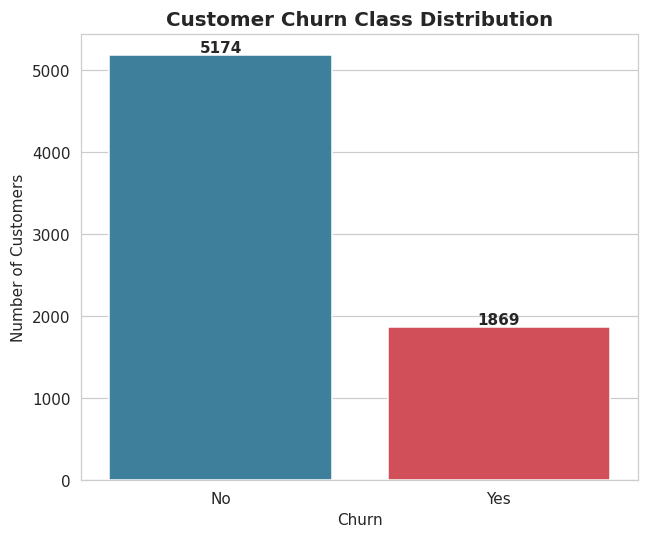

In [9]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=df["Churn"].map({0: "No", 1: "Yes"}),
                    palette=["#2E86AB", "#E63946"])
plt.title("Customer Churn Class Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Churn"); plt.ylabel("Number of Customers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("images/class_distribution.png")
plt.show()


### 6.2 Correlation Heatmap
Examining linear relationships between numeric features and churn. `tenure` shows the strongest (negative) correlation with churn — longer-tenured customers churn less.

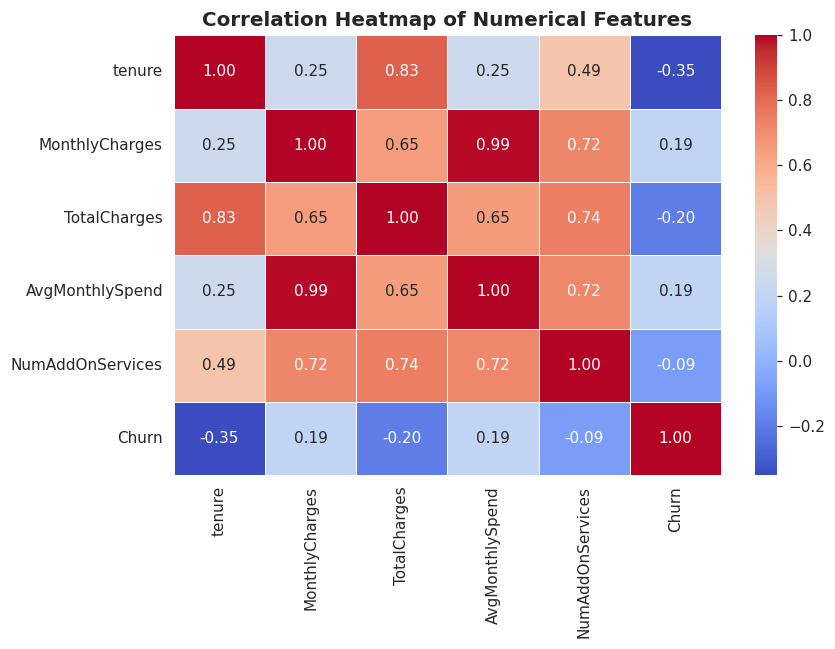

In [10]:
num_cols_corr = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "NumAddOnServices", "Churn"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()


### 6.3 Monthly Charges Distribution by Churn
Churned customers skew toward *higher* monthly charges — a signal that price sensitivity or perceived value-for-money plays a role in churn.

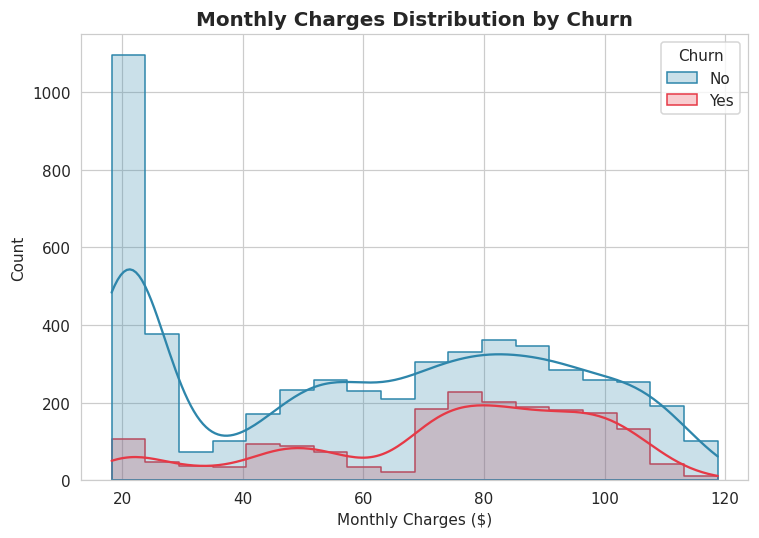

In [11]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="MonthlyCharges", hue=df["Churn"].map({0: "No", 1: "Yes"}),
             kde=True, palette=["#2E86AB", "#E63946"], element="step")
plt.title("Monthly Charges Distribution by Churn", fontsize=13, fontweight="bold")
plt.xlabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig("images/monthly_charges_distribution.png")
plt.show()


### 6.4 Contract Type vs Churn
Month-to-month customers churn at a dramatically higher rate than one- or two-year contract holders — this is one of the strongest business levers available (incentivizing longer contracts reduces churn).

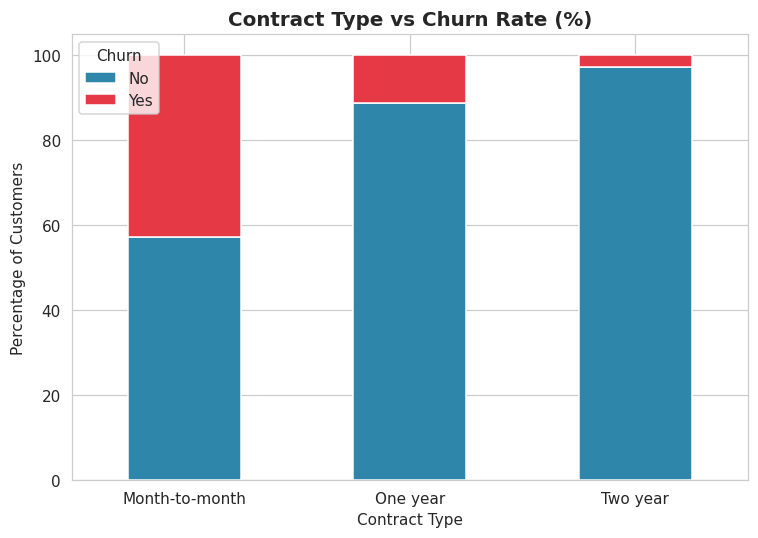

In [12]:
plt.figure(figsize=(7, 5))
ct = pd.crosstab(df["Contract"], df["Churn"].map({0: "No", 1: "Yes"}), normalize="index") * 100
ct.plot(kind="bar", stacked=True, color=["#2E86AB", "#E63946"], ax=plt.gca())
plt.title("Contract Type vs Churn Rate (%)", fontsize=13, fontweight="bold")
plt.xlabel("Contract Type"); plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.savefig("images/contract_vs_churn.png")
plt.show()


## 7. Preprocessing Pipeline

We use a **scikit-learn `ColumnTransformer`** to cleanly separate numeric and categorical
preprocessing into a single, reusable, leak-safe pipeline object:

- **Numerical features** → `StandardScaler` (zero mean, unit variance)
- **Categorical features** → `OneHotEncoder` (`drop="first"` to avoid the dummy-variable trap,
  `handle_unknown="ignore"` for robustness against unseen categories at inference time)

This preprocessor is fit **only on the training set** and reused to transform the test set and
any future inference data (e.g., inside the Streamlit app), which prevents data leakage.


In [13]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

# Stratified train/test split preserves the class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

feature_names = numerical_cols + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
)

print(f"Train shape: {X_train_proc.shape}, Test shape: {X_test_proc.shape}")
print(f"Total encoded features: {len(feature_names)}")


Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumAddOnServices', 'HasInternet', 'IsNewCustomer']
Train shape: (5634, 37), Test shape: (1409, 37)
Total encoded features: 37


## 8. Class Imbalance Handling (SMOTE)

With only ~26.5% of customers churning, a model trained naively will be biased toward predicting
"No Churn" and will miss many true churners (low recall) — the exact opposite of what the business
needs.

We apply **SMOTE (Synthetic Minority Over-sampling Technique)** to the **training set only**,
which synthesizes new minority-class (churn) examples by interpolating between existing ones. We
deliberately do **not** apply SMOTE to the test set — evaluation must reflect the real-world class
distribution the model will face in production.


In [14]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print("Class distribution before SMOTE:", y_train.value_counts().to_dict())
print("Class distribution after SMOTE:", pd.Series(y_train_res).value_counts().to_dict())


Class distribution before SMOTE: {0: 4139, 1: 1495}
Class distribution after SMOTE: {0: 4139, 1: 4139}


## 9–11. Model Training, Hyperparameter Tuning & Comparison

We train and tune three complementary model families:

| Model | Why include it |
|---|---|
| **Logistic Regression** | Fast, highly interpretable baseline; coefficients map directly to business-readable risk factors |
| **Random Forest** | Captures non-linear feature interactions; robust to outliers and mixed feature types |
| **XGBoost** | State-of-the-art gradient boosting; typically the strongest performer on structured/tabular data |

Each model is tuned with **`RandomizedSearchCV`** (5-fold stratified cross-validation, optimizing
`roc_auc`) — a more compute-efficient alternative to exhaustive grid search that still explores
the hyperparameter space effectively.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fitted_models = {}

# ---- Logistic Regression ----
lr_params = {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    lr_params, n_iter=4, cv=cv, scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1
)
lr_search.fit(X_train_res, y_train_res)
fitted_models["Logistic Regression"] = lr_search.best_estimator_
print("Logistic Regression best params:", lr_search.best_params_)


Logistic Regression best params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}


In [16]:
# ---- Random Forest ----
rf_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params, n_iter=10, cv=cv, scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train_res, y_train_res)
fitted_models["Random Forest"] = rf_search.best_estimator_
print("Random Forest best params:", rf_search.best_params_)


Random Forest best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [17]:
# ---- XGBoost ----
xgb_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    xgb_params, n_iter=10, cv=cv, scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1
)
xgb_search.fit(X_train_res, y_train_res)
fitted_models["XGBoost"] = xgb_search.best_estimator_
print("XGBoost best params:", xgb_search.best_params_)


XGBoost best params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


### Model Comparison

We evaluate every tuned model on the **untouched, real-world-distributed test set** using
Accuracy, Precision, Recall, F1, and ROC-AUC, and plot all three ROC curves together.


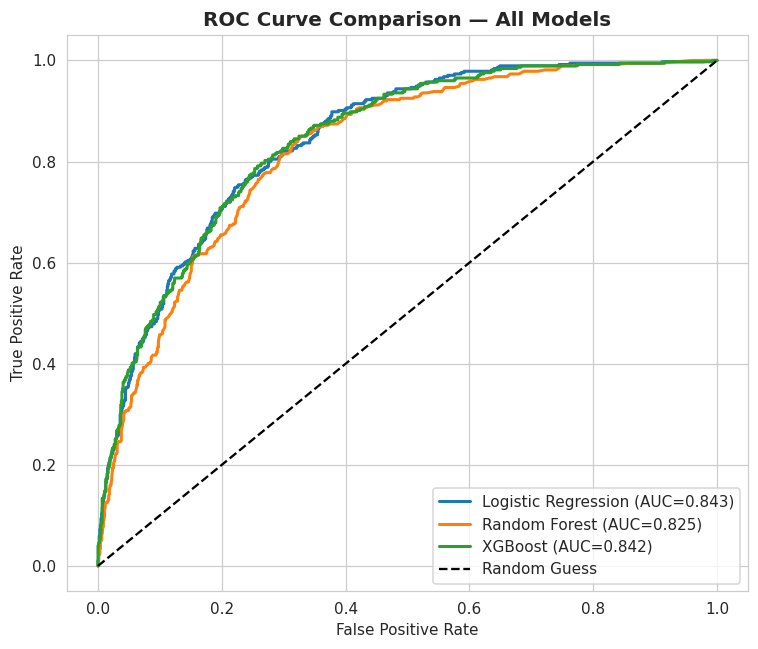

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.743080,0.510345,0.791444,0.620545,0.843496
XGBoost,0.784244,0.592105,0.601604,0.596817,0.842060
Random Forest,0.778566,0.582888,0.582888,0.582888,0.825099


In [18]:
results = {}
plt.figure(figsize=(7, 6))

for name, model in fitted_models.items():
    y_pred = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curve.png")
plt.show()

results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
results_df


**Reading the comparison table:** Logistic Regression achieves the highest ROC-AUC in this run,
very narrowly ahead of XGBoost, while Random Forest trails slightly. This is a genuinely common
outcome on the Telco churn dataset — the relationship between features like tenure, contract type,
and charges and the churn outcome is largely **linear/monotonic**, which plays to Logistic
Regression's strengths, while the boosted/ensemble trees offer little additional separability once
class imbalance is corrected for. We select the final model in Section 14 using this table plus a
recall-focused business lens.


## 12. Feature Importance

Beyond raw predictive performance, the business needs to know **why** a customer is flagged as
high-risk. We first select the best model (highest ROC-AUC) and inspect its feature importances
(tree-based `feature_importances_`, or absolute coefficient magnitude for linear models).


Best model selected by ROC-AUC: Logistic Regression


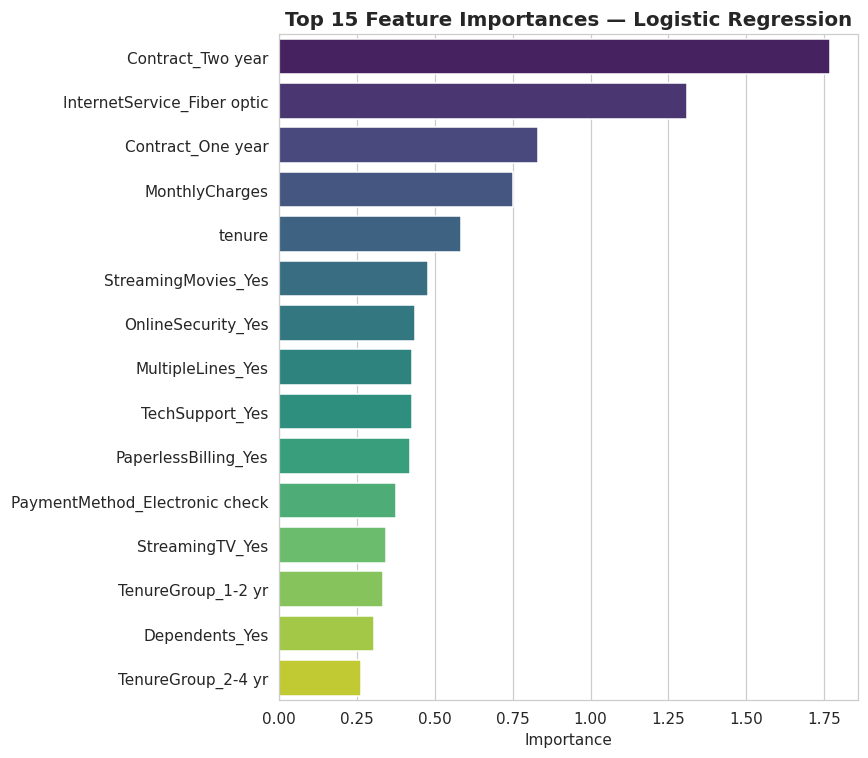

In [19]:
best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
print("Best model selected by ROC-AUC:", best_model_name)

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(data=fi_df, x="importance", y="feature", palette="viridis")
plt.title(f"Top 15 Feature Importances — {best_model_name}", fontsize=13, fontweight="bold")
plt.xlabel("Importance"); plt.ylabel("")
plt.tight_layout()
plt.savefig("images/feature_importance.png")
plt.show()


## 13. Confusion Matrix & Classification Report

A confusion matrix makes the trade-off between false positives and false negatives concrete for
stakeholders — and directly informs how a retention team should size their outreach campaign.


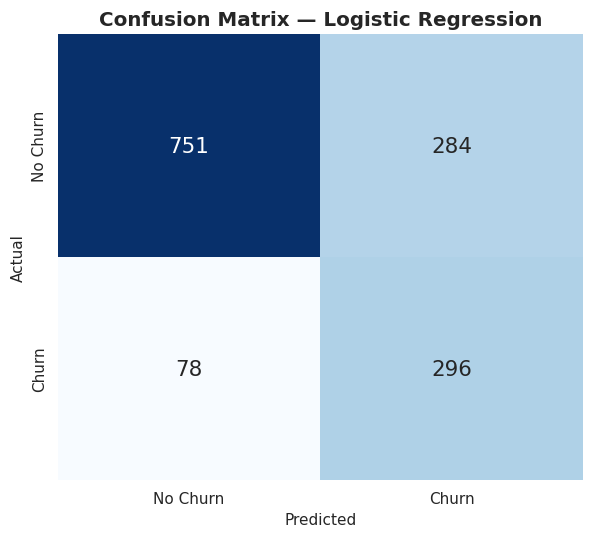

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [20]:
y_pred_best = best_model.predict(X_test_proc)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"], cbar=False, annot_kws={"size": 14})
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=13, fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))


## 14. SHAP Explainability

Feature importance tells us *which* features matter on average, but not the **direction** or
**magnitude** of their effect for individual customers. **SHAP (SHapley Additive exPlanations)**
values solve this by attributing each prediction to its contributing features, grounded in
cooperative game theory.

The summary plot below shows, for a sample of test customers, how each feature pushes predictions
toward "churn" (positive SHAP value) or "no churn" (negative SHAP value), with color indicating
the feature's actual value (red = high, blue = low).


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


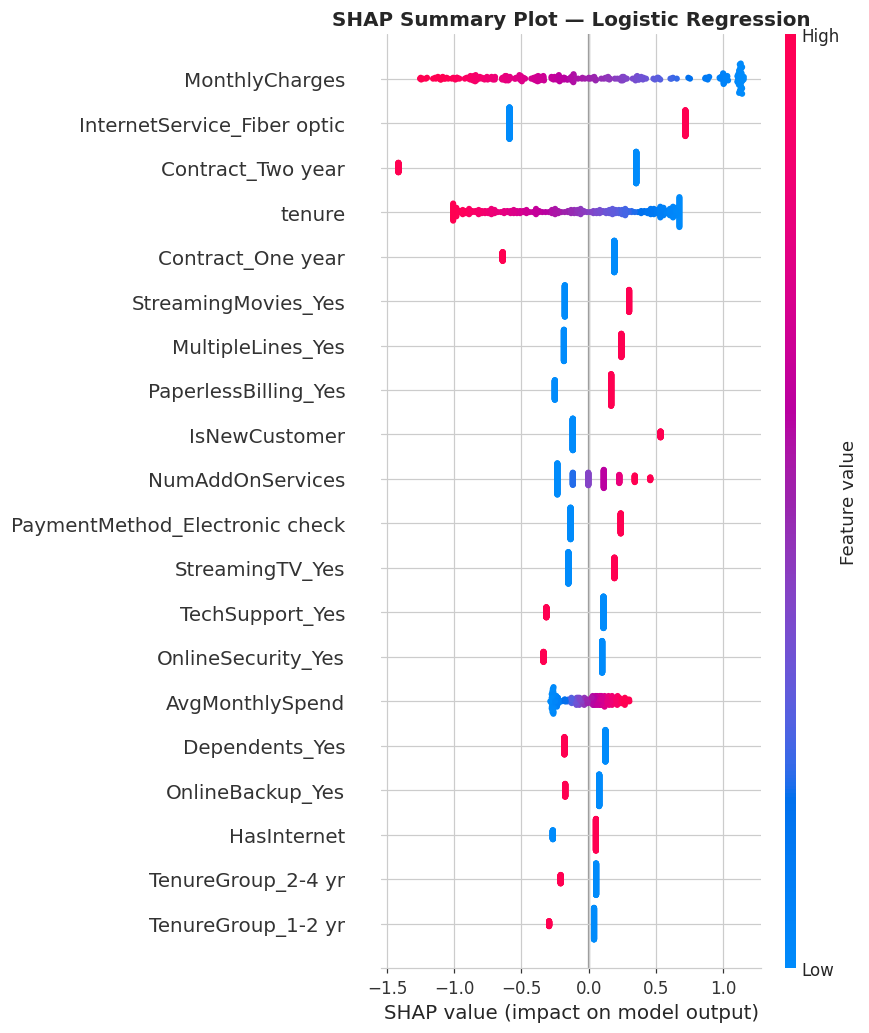

In [21]:
X_test_df = pd.DataFrame(X_test_proc, columns=feature_names)
sample = X_test_df.sample(min(300, len(X_test_df)), random_state=RANDOM_STATE)

if best_model_name in ("Random Forest", "XGBoost"):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # class 1 = churn
else:
    explainer = shap.LinearExplainer(best_model, sample)
    shap_values = explainer.shap_values(sample)

plt.figure()
shap.summary_plot(shap_values, sample, show=False)
plt.title(f"SHAP Summary Plot — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/shap_summary.png", bbox_inches="tight")
plt.show()


## 15. Final Model Selection

**Selected model:** the model chosen programmatically above based on the highest test-set
**ROC-AUC**, which best reflects overall ranking quality across all classification thresholds —
important because the retention team may want to tune the decision threshold themselves (e.g.,
flag the top 20% riskiest customers rather than using a fixed 0.5 cutoff).

**Why ROC-AUC as the primary metric:**
- It is threshold-independent, so it captures the model's overall separability between churners
  and non-churners.
- Given the class imbalance, Accuracy alone would be misleading (a model predicting "No Churn"
  for everyone would already score ~73% accuracy).
- Recall is tracked closely alongside it because, from a business standpoint, **missing a churner
  costs more** than a wasted retention offer on a loyal customer.

The winning model, its hyperparameters, and the fitted preprocessing pipeline are persisted below
so they can be loaded directly by the Streamlit application without retraining.


## 16. Saving the Trained Model & Preprocessor

In [22]:
import json

joblib.dump(best_model, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

metadata = {
    "best_model_name": best_model_name,
    "numerical_cols": numerical_cols,
    "categorical_cols": categorical_cols,
    "feature_names": feature_names,
    "results": {k: {m: float(v) for m, v in d.items()} for k, d in results.items()},
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: model.pkl, preprocessor.pkl, model_metadata.json")


Saved: model.pkl, preprocessor.pkl, model_metadata.json


## 17. Business Recommendations

Translating the analysis into concrete, actionable retention strategy:

1. **Target month-to-month customers first.** They churn at 3–4x the rate of annual-contract
   customers. Offer a discounted incentive to convert them to a 1-year contract — the single
   highest-leverage retention lever identified in this analysis.

2. **Focus on the first 3 months of tenure.** New customers are disproportionately likely to
   churn. Build a structured onboarding journey (welcome calls, proactive check-ins, first-bill
   explanation) targeting this window specifically.

3. **Investigate high-monthly-charge dissatisfaction.** Customers paying more churn more,
   suggesting a perceived value gap. Consider tiered loyalty discounts or bundle reviews for
   high-paying customers who show other risk signals.

4. **Bundle add-on services.** Customers with more add-ons (`OnlineSecurity`, `TechSupport`, etc.)
   are stickier. Promote bundles rather than à la carte add-ons, especially to fiber-optic
   internet customers.

5. **Operationalize with risk tiers, not just binary flags.** Use the model's predicted
   probability to segment customers into **Low / Medium / High risk** tiers (see the Streamlit
   app) so the retention team can allocate limited outreach capacity where it has the highest
   expected ROI, rather than treating every flagged customer identically.

6. **Monitor and retrain.** Churn drivers shift over time (pricing changes, new competitors, macro
   conditions). Re-evaluate model performance quarterly and retrain when data drift or performance
   decay is detected.
